In [14]:
import xarray as xr
import numpy as np
import sys
sys.path.append('/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder')
import utils as ut
import dpa_ensemble as de
from dask.distributed import Client

In [2]:
import torch
import torch.nn as nn


class LinearMultiQuantileRegressor(nn.Module):
    def __init__(self, n_features: int, n_cells: int, n_quantiles: int):
        super().__init__()
        self.n_cells = n_cells
        self.n_quantiles = n_quantiles
        self.linear = nn.Linear(n_features, n_cells * n_quantiles)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (batch_size, n_features)
        returns: (batch_size, n_cells, n_quantiles)
        """
        out = self.linear(x)  # (B, C * Q)
        out = out.view(x.size(0), self.n_cells, self.n_quantiles)
        return out

In [6]:
#################
### Load Data ###
#################

z500_eth, mask_x_te_eth_fact, ds_test_eth_fact, ds_test_eth_cf, x_te_reduced_eth_fact, x_te_reduced_eth_cf, mean_gmt, std_gmt = de.load_eth_test_data(
    settings_file_path = "/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder/joint_training/v5_dpa_train_settings_home.json",
    standardize_predictors=1)

print(z500.shape)

torch.Size([14307, 1024])
torch.Size([14307, 1024])
ATTENTION: Z500 PC time-series is standardized manually here
z500 dataset shape (14307, 1001)
torch.Size([14307, 1001])


In [5]:
print(z500.shape)

torch.Size([14307, 1001])


In [7]:
##################
### Load Model ###
##################


model_path = "/work2/fl53wumy-llaae_ws_new/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/baseline_quantile_regression/v5_data_quantile_regression_ger_gradient_descent_2026-03-25_13-07/"

device = "cuda" if torch.cuda.is_available() else "cpu"

# load checkpoint
ckpt = torch.load(f"{model_path}/checkpoint_epoch_100.pth", map_location=device, weights_only=False)

# rebuild model
model = LinearMultiQuantileRegressor(
    n_features=ckpt["n_features"],
    n_cells=ckpt["n_cells"],
    n_quantiles=ckpt["n_quantiles"],
).to(device)

model.load_state_dict(ckpt["model_state_dict"])
model.eval()

# predict
#X_new = torch.randn(100, 1001).to(device)

with torch.no_grad():
    preds = model(z500_eth)

print(preds.shape)  # (100, 648, 3)

torch.Size([14307, 648, 19])


In [26]:
###########
### DAE ###
###########

dae_ensemble = ("/work2/fl53wumy-llaae_ws_new/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/"
                "dpa_output/v5_model/_devicecpu100_6_100_100_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.5_bs128_bnisFalse_lr0.0001_pene0/"
                "eth_test_set_reference_period_1950-1980_v5_dpa_train_settings_home.json/dpa_ensemble_after_50_epochs/eth_ensemble_after_50_epochs/"
                "raw_ETH_gen_dpa_ens_50_dataset.nc")


trefht = xr.open_dataset(
    dae_ensemble,
    chunks={
        "ensemble_member": 100,
        "time": 4000,
        "lat_x_lon": 648,
    }
)["TREFHT"]

q90 = trefht.quantile(
    q=np.linspace(0.05, 0.95, 19),
    dim="ensemble_member",
    skipna=True,
).compute()

print(q90.shape)


# parallel option:

#client = Client(n_workers=4, threads_per_worker=2, memory_limit="7GB")

#trefht = xr.open_dataset(
#    dae_ensemble,
#    chunks={"ensemble_member": 100, "time": 2000, "lat_x_lon": 324}
#)["TREFHT"]

#q90 = trefht.quantile(0.9, dim="ensemble_member", skipna=True).compute()



(19, 14307, 648)


In [18]:
dae_eth_fact

<xarray.Dataset> Size: 4GB
Dimensions:          (ensemble_member: 100, time: 14307, lat_x_lon: 648)
Coordinates:
  * ensemble_member  (ensemble_member) int64 800B 1 2 3 4 5 ... 96 97 98 99 100
  * time             (time) object 114kB 1850-06-02 00:00:00 ... 2100-08-31 0...
  * lat_x_lon        (lat_x_lon) int64 5kB 0 1 2 3 4 5 ... 643 644 645 646 647
Data variables:
    TREFHT           (ensemble_member, time, lat_x_lon) float32 4GB ...

In [31]:
dae_eth_fact_quantiles = q90
print(x_te_reduced_eth_fact.numpy().shape)
print(dae_eth_fact_quantiles.shape)
print(preds.shape)

(14307, 648)
(19, 14307, 648)
torch.Size([14307, 648, 19])


r2 DAE: 0.8683156421351192
r2 QR: 0.8477418


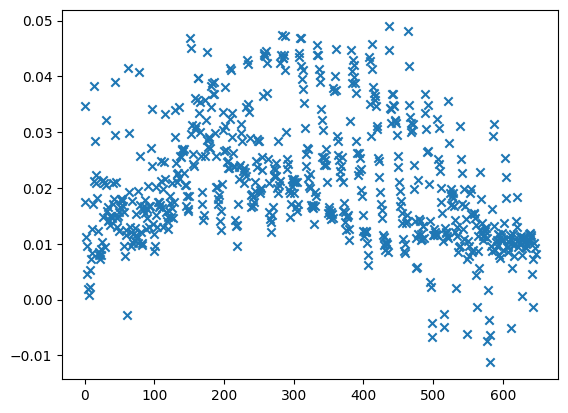

In [42]:
import matplotlib.pyplot as plt

def r2_per_feature(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2, axis=0)
    ss_tot = np.sum((y_true - np.mean(y_true, axis=0)) ** 2, axis=0)
    return 1 - ss_res / ss_tot

r2_dae = r2_per_feature(x_te_reduced_eth_fact.numpy(), dae_eth_fact_quantiles.values[9,:,:])
r2_qr = r2_per_feature(x_te_reduced_eth_fact.numpy(), preds.numpy()[:,:,9])
print("r2 DAE:", np.mean(r2_dae))
print("r2 QR:", np.mean(r2_qr))

plt.scatter(range(648), r2_dae - r2_qr, marker='x')
#plt.scatter(range(648), r2_qr, marker='x')


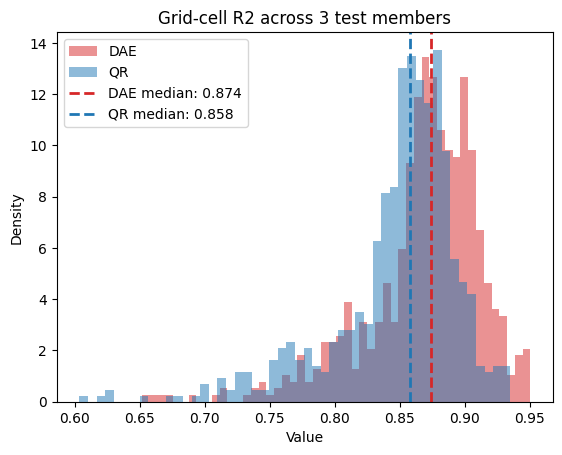

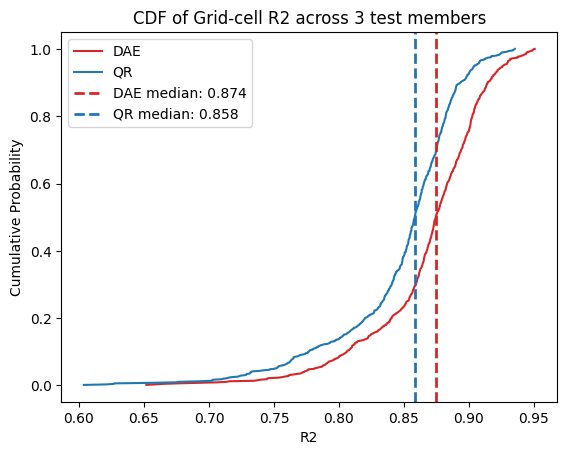

In [45]:
# load tensor
#x = r2_dae
#x_cf = r2_qr

# flatten and convert
data_dae = r2_dae.flatten() #.numpy()
data_qr = r2_qr.flatten() #.numpy()

# compute medians
median = np.nanmedian(data_dae)
median_cf = np.nanmedian(data_qr)

# plot histograms
plt.hist(data_dae, bins=50, density=True, label="DAE", color="tab:red", alpha=0.5)
plt.hist(data_qr, bins=50, density=True, label="QR", color="tab:blue", alpha=0.5)

# add median lines
plt.axvline(median, color="tab:red", linestyle="--", linewidth=2, label=f"DAE median: {median:.3f}")
plt.axvline(median_cf, color="tab:blue", linestyle="--", linewidth=2, label=f"QR median: {median_cf:.3f}")

plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Grid-cell R2 across 3 test members")
plt.legend()
#plt.savefig("r2_spatial.png", dpi = 600)

plt.show()

data_dae = data_dae[~np.isnan(data_dae)]
data_qr = data_qr[~np.isnan(data_qr)]

# sort data
x_dae = np.sort(data_dae)
x_qr = np.sort(data_qr)

# empirical CDF
y_dae = np.arange(1, len(x_dae)+1) / len(x_dae)
y_qr = np.arange(1, len(x_qr)+1) / len(x_qr)

# medians
median = np.median(x_dae)
median_cf = np.median(x_qr)

# plot
plt.plot(x_dae, y_dae, label="DAE", color="tab:red")
plt.plot(x_qr, y_qr, label="QR", color="tab:blue")

# median lines
plt.axvline(median, color="tab:red", linestyle="--", linewidth=2,
            label=f"DAE median: {median:.3f}")
plt.axvline(median_cf, color="tab:blue", linestyle="--", linewidth=2,
            label=f"QR median: {median_cf:.3f}")

plt.xlabel("R2")
plt.ylabel("Cumulative Probability")
plt.title("CDF of Grid-cell R2 across 3 test members")
plt.legend()

plt.show()

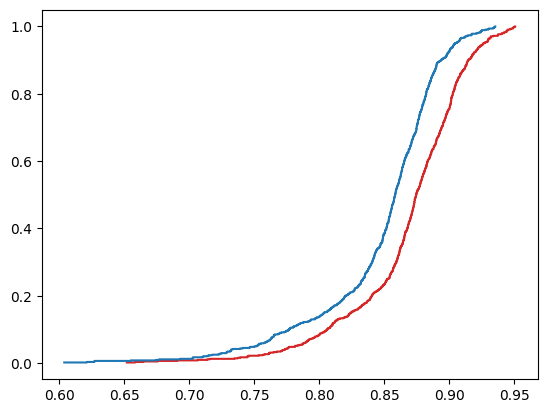

In [46]:
plt.step(x_dae, y_dae, where="post", label="DAE", color="tab:red")
plt.step(x_qr, y_qr, where="post", label="QR", color="tab:blue")

below shape: (19, 14307, 648)
below shape: (19, 14307, 648)
Coverage shape: (19, 648)
coverage_qr_median shape (19,)
(19, 648)


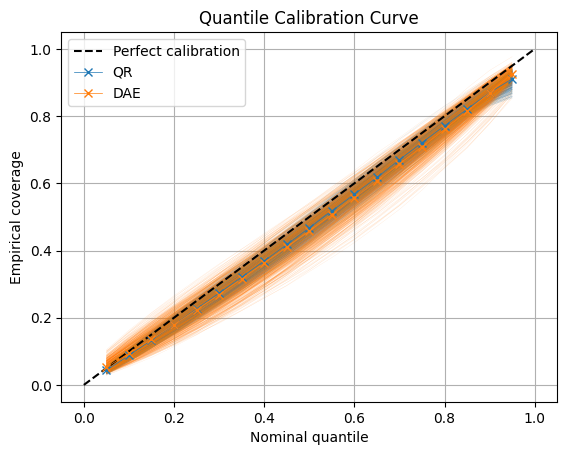

0.0312776594453212 0.027014748025442067


In [77]:
def quantile_coverage(y_true, y_pred_q, quantiles):
    """
    y_true: (T, G)
    y_pred_q: (Q, T, G)
    quantiles: (Q,)
    """
    # expand truth to match quantile dimension
    y_true_exp = y_true[None, :, :]  # (1, T, G)

    # indicator: truth <= predicted quantile
    below = y_true_exp <= y_pred_q   # (Q, T, G)
    print("below shape:", below.shape)

    # average over all samples
    coverage_all_gcs = np.mean(below, axis=1)
    coverage_mean = np.mean(below, axis=(1, 2))  # (Q,)

    return coverage_mean, coverage_all_gcs

quantiles = np.linspace(0.05, 0.95, 19)  # or your actual quantile levels

coverage_dae_mean, coverage_dae = quantile_coverage(x_te_reduced_eth_fact.numpy(), dae_eth_fact_quantiles.values, quantiles=np.linspace(0.05, 0.95, 19))
coverage_qr_mean, coverage_qr = quantile_coverage(x_te_reduced_eth_fact.numpy(), preds.numpy().transpose(2,0,1), quantiles=np.linspace(0.05, 0.95, 19))
print("Coverage shape:", coverage_dae.shape)

# median calibration
coverage_dae_median = np.median(coverage_dae, axis=1)
coverage_qr_median = np.median(coverage_qr, axis=1)
print("coverage_qr_median shape", coverage_qr_median.shape)

print(coverage_dae.shape)

plt.plot(quantiles, coverage_qr, color = "tab:blue",alpha=0.4, linewidth=0.1)
plt.plot(quantiles, coverage_dae, color="tab:orange",alpha=0.4, linewidth=0.1)
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")

plt.plot(quantiles, coverage_qr_median, color="tab:blue", marker="x", alpha=1.0, linewidth=0.5, label="QR")
plt.plot(quantiles, coverage_dae_median, color="tab:orange", marker="x", alpha=1.0, linewidth=0.5, label="DAE")

plt.xlabel("Nominal quantile")
plt.ylabel("Empirical coverage")
plt.title("Quantile Calibration Curve")
plt.legend()
plt.grid(True)

plt.show()

mae_dae = np.mean(np.abs(coverage_dae_median - quantiles))
mae_qr = np.mean(np.abs(coverage_qr_median - quantiles))

print(mae_dae, mae_qr)

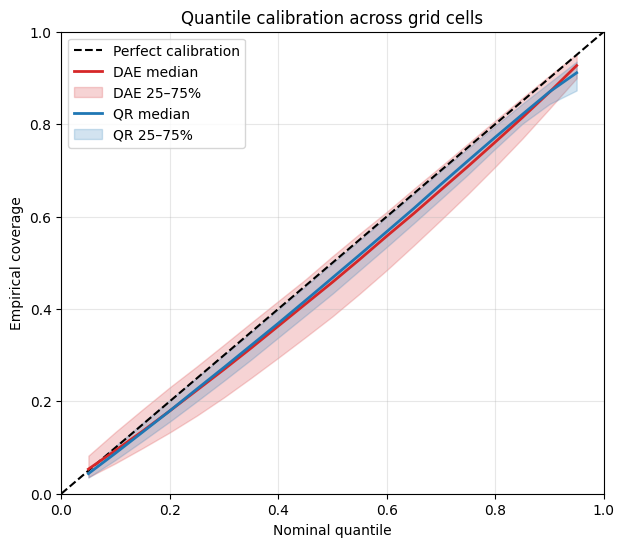

In [80]:
import numpy as np
import matplotlib.pyplot as plt

def calibration_summary(coverage_all_gcs):
    """
    coverage_all_gcs: (Q, G)
    returns per-quantile median, p25, p75 across grid cells
    """
    median = np.nanmedian(coverage_all_gcs, axis=1)   # (Q,)
    p25 = np.nanpercentile(coverage_all_gcs, 5, axis=1)
    p75 = np.nanpercentile(coverage_all_gcs, 95, axis=1)
    return median, p25, p75

# summarize DAE
dae_med, dae_p5, dae_p95 = calibration_summary(coverage_dae)

# summarize QR
qr_med, qr_p5, qr_p95 = calibration_summary(coverage_qr)

# plot
plt.figure(figsize=(7, 6))

# perfect calibration
plt.plot([0, 1], [0, 1], "k--", linewidth=1.5, label="Perfect calibration")

# DAE median + IQR band
plt.plot(quantiles, dae_med, color="tab:red", linewidth=2, label="DAE median")
plt.fill_between(quantiles, dae_p5, dae_p95, color="tab:red", alpha=0.2, label="DAE 25–75%")

# QR median + IQR band
plt.plot(quantiles, qr_med, color="tab:blue", linewidth=2, label="QR median")
plt.fill_between(quantiles, qr_p5, qr_p95, color="tab:blue", alpha=0.2, label="QR 25–75%")

plt.xlabel("Nominal quantile")
plt.ylabel("Empirical coverage")
plt.title("Quantile calibration across grid cells")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [51]:
dae_eth_fact_quantiles.values.shape

(19, 14307, 648)